# Options Greeks: From First Principles to Interactive Visualization

This notebook builds an intuition for **options Greeks** from the ground up. We start with the Black-Scholes model, derive each Greek analytically, implement them in code, and visualize how they behave across different market conditions.

**Prerequisites:** Basic calculus (partial derivatives), probability (normal distribution), and familiarity with call/put options.

---

## Table of Contents

1. [The Black-Scholes Foundation](#1-the-black-scholes-foundation)
2. [Delta — Sensitivity to Underlying Price](#2-delta)
3. [Gamma — Rate of Change of Delta](#3-gamma)
4. [Theta — Time Decay](#4-theta)
5. [Vega — Sensitivity to Volatility](#5-vega)
6. [Rho — Sensitivity to Interest Rates](#6-rho)
7. [Greeks in Action: Portfolio Analysis](#7-greeks-in-action)
8. [Greek Surfaces: 3D Visualization](#8-greek-surfaces)
9. [Practical Exercises](#9-exercises)

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

CALL_COLOR = '#2196F3'
PUT_COLOR = '#F44336'
ACCENT_COLOR = '#4CAF50'

---
## 1. The Black-Scholes Foundation <a id='1-the-black-scholes-foundation'></a>

### The Model

The Black-Scholes model prices European options under these assumptions:
- The underlying follows geometric Brownian motion: $dS = \mu S \, dt + \sigma S \, dW$
- No dividends, no transaction costs, continuous trading
- Constant risk-free rate $r$ and volatility $\sigma$

### Pricing Formulas

$$C = S \, N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S \, N(-d_1)$$

where:

$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

and $N(\cdot)$ is the standard normal CDF.

### What Are the Greeks?

Greeks are **partial derivatives** of the option price with respect to its inputs. They quantify how sensitive the option price is to changes in each variable:

| Greek | Symbol | Measures sensitivity to | Mathematical definition |
|-------|--------|------------------------|------------------------|
| Delta | $\Delta$ | Underlying price $S$ | $\partial V / \partial S$ |
| Gamma | $\Gamma$ | Underlying price (2nd order) | $\partial^2 V / \partial S^2$ |
| Theta | $\Theta$ | Time $T$ | $\partial V / \partial t$ |
| Vega  | $\nu$ | Volatility $\sigma$ | $\partial V / \partial \sigma$ |
| Rho   | $\rho$ | Interest rate $r$ | $\partial V / \partial r$ |

In [2]:
class BlackScholes:
    """Black-Scholes pricing and Greeks for European options."""

    def __init__(self, S, K, T, r, sigma):
        self.S = np.asarray(S, dtype=float)
        self.K = np.asarray(K, dtype=float)
        self.T = np.asarray(T, dtype=float)
        self.r = np.asarray(r, dtype=float)
        self.sigma = np.asarray(sigma, dtype=float)
        self._compute_d()

    def _compute_d(self):
        sqrt_T = np.sqrt(np.maximum(self.T, 1e-10))
        self.d1 = (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * sqrt_T)
        self.d2 = self.d1 - self.sigma * sqrt_T

    # --- Prices ---
    def call_price(self):
        return self.S * norm.cdf(self.d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(self.d2)

    def put_price(self):
        return self.K * np.exp(-self.r * self.T) * norm.cdf(-self.d2) - self.S * norm.cdf(-self.d1)

    # --- Delta: dV/dS ---
    def call_delta(self):
        return norm.cdf(self.d1)

    def put_delta(self):
        return norm.cdf(self.d1) - 1.0

    # --- Gamma: d²V/dS² (same for calls and puts) ---
    def gamma(self):
        sqrt_T = np.sqrt(np.maximum(self.T, 1e-10))
        return norm.pdf(self.d1) / (self.S * self.sigma * sqrt_T)

    # --- Theta: dV/dt (per calendar day) ---
    def call_theta(self):
        sqrt_T = np.sqrt(np.maximum(self.T, 1e-10))
        term1 = -(self.S * norm.pdf(self.d1) * self.sigma) / (2 * sqrt_T)
        term2 = -self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(self.d2)
        return (term1 + term2) / 365.0

    def put_theta(self):
        sqrt_T = np.sqrt(np.maximum(self.T, 1e-10))
        term1 = -(self.S * norm.pdf(self.d1) * self.sigma) / (2 * sqrt_T)
        term2 = self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(-self.d2)
        return (term1 + term2) / 365.0

    # --- Vega: dV/dσ (per 1% move, same for calls and puts) ---
    def vega(self):
        sqrt_T = np.sqrt(np.maximum(self.T, 1e-10))
        return self.S * norm.pdf(self.d1) * sqrt_T / 100.0

    # --- Rho: dV/dr (per 1% move) ---
    def call_rho(self):
        return self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(self.d2) / 100.0

    def put_rho(self):
        return -self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(-self.d2) / 100.0


# Quick sanity check
bs = BlackScholes(S=100, K=100, T=0.25, r=0.05, sigma=0.20)
print(f"ATM Call: ${bs.call_price():.4f}")
print(f"ATM Put:  ${bs.put_price():.4f}")
print(f"Put-Call Parity check: C - P = {bs.call_price() - bs.put_price():.4f}, "
      f"S - Ke^(-rT) = {100 - 100*np.exp(-0.05*0.25):.4f}")

ATM Call: $4.6150
ATM Put:  $3.3728
Put-Call Parity check: C - P = 1.2422, S - Ke^(-rT) = 1.2422


### Visualizing the Option Price Surface

Before diving into Greeks, let's see how the call price varies with the underlying price and time to expiry. The Greeks are the *slopes* and *curvatures* of this surface.

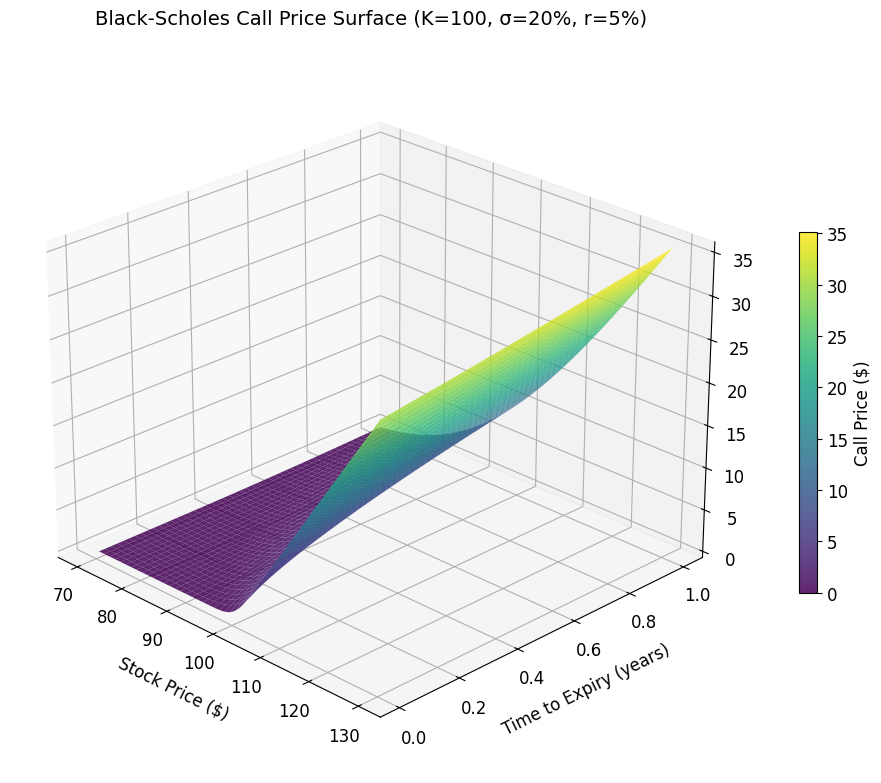

In [4]:
S_range = np.linspace(70, 130, 100)
T_range = np.linspace(0.01, 1.0, 100)
S_grid, T_grid = np.meshgrid(S_range, T_range)

bs_grid = BlackScholes(S=S_grid, K=100, T=T_grid, r=0.05, sigma=0.20)
call_prices = bs_grid.call_price()

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(S_grid, T_grid, call_prices, cmap='viridis', alpha=0.85, edgecolor='none')
ax.set_xlabel('Stock Price ($)', fontsize=12, labelpad=10)
ax.set_ylabel('Time to Expiry (years)', fontsize=12, labelpad=10)
ax.set_title('Black-Scholes Call Price Surface (K=100, σ=20%, r=5%)', fontsize=14, pad=20)
ax.view_init(elev=25, azim=-45)
fig.colorbar(surf, shrink=0.5, label='Call Price ($)')
plt.tight_layout()
plt.show()

---
## 2. Delta ($\Delta$) — Sensitivity to Underlying Price <a id='2-delta'></a>

### Derivation

Delta is the first partial derivative of the option price with respect to $S$:

$$\Delta_{\text{call}} = \frac{\partial C}{\partial S} = N(d_1)$$

$$\Delta_{\text{put}} = \frac{\partial P}{\partial S} = N(d_1) - 1$$

### Three Interpretations

1. **Hedge ratio:** To delta-hedge one short call, hold $\Delta$ shares of stock.
2. **Dollar sensitivity:** If the stock moves 1 dollar, the option moves approximately $\Delta$ dollars.
3. **Probability proxy:** $N(d_2)$ is the risk-neutral probability the option expires ITM. $\Delta = N(d_1)$ is close but not identical — the distinction matters for large moves.

### Key Properties
- Call delta: $0 \le \Delta_C \le 1$
- Put delta: $-1 \le \Delta_P \le 0$
- Put-call parity implies $\Delta_C - \Delta_P = 1$
- ATM options have $|\Delta| \approx 0.5$

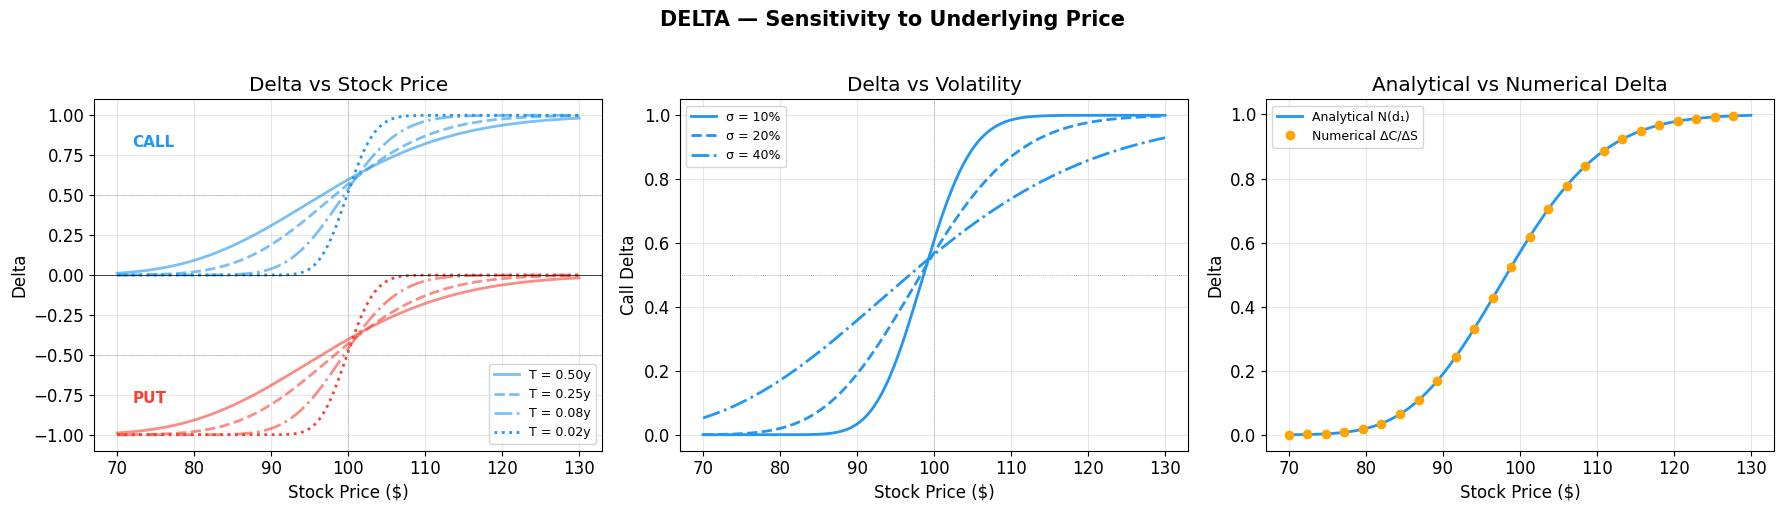

In [5]:
S_range = np.linspace(70, 130, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Delta vs stock price for different times to expiry
ax = axes[0]
for T, ls in [(0.5, '-'), (0.25, '--'), (0.08, '-.'), (0.02, ':')]:
    bs = BlackScholes(S=S_range, K=100, T=T, r=0.05, sigma=0.20)
    ax.plot(S_range, bs.call_delta(), ls, label=f'T = {T:.2f}y', color=CALL_COLOR, alpha=0.6 + 0.4*(T==0.02))
    ax.plot(S_range, bs.put_delta(), ls, color=PUT_COLOR, alpha=0.6 + 0.4*(T==0.02))
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(0.5, color='gray', linewidth=0.5, linestyle=':')
ax.axhline(-0.5, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(100, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Stock Price ($)')
ax.set_ylabel('Delta')
ax.set_title('Delta vs Stock Price')
ax.legend(fontsize=9)
ax.text(72, 0.8, 'CALL', color=CALL_COLOR, fontsize=11, fontweight='bold')
ax.text(72, -0.8, 'PUT', color=PUT_COLOR, fontsize=11, fontweight='bold')

# Panel 2: Delta vs stock price for different volatilities
ax = axes[1]
for sigma, ls in [(0.10, '-'), (0.20, '--'), (0.40, '-.')]: 
    bs = BlackScholes(S=S_range, K=100, T=0.25, r=0.05, sigma=sigma)
    ax.plot(S_range, bs.call_delta(), ls, label=f'σ = {sigma:.0%}', color=CALL_COLOR)
ax.axhline(0.5, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(100, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Stock Price ($)')
ax.set_ylabel('Call Delta')
ax.set_title('Delta vs Volatility')
ax.legend(fontsize=9)

# Panel 3: Numerical verification — delta as finite difference
ax = axes[2]
dS = 0.01
bs_up = BlackScholes(S=S_range + dS, K=100, T=0.25, r=0.05, sigma=0.20)
bs_dn = BlackScholes(S=S_range - dS, K=100, T=0.25, r=0.05, sigma=0.20)
bs_mid = BlackScholes(S=S_range, K=100, T=0.25, r=0.05, sigma=0.20)
numerical_delta = (bs_up.call_price() - bs_dn.call_price()) / (2 * dS)
analytical_delta = bs_mid.call_delta()

ax.plot(S_range, analytical_delta, '-', label='Analytical N(d₁)', color=CALL_COLOR, linewidth=2)
ax.plot(S_range[::20], numerical_delta[::20], 'o', label='Numerical ΔC/ΔS', color='orange', markersize=6)
ax.set_xlabel('Stock Price ($)')
ax.set_ylabel('Delta')
ax.set_title('Analytical vs Numerical Delta')
ax.legend(fontsize=9)

plt.suptitle('DELTA — Sensitivity to Underlying Price', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Delta Hedging Simulation

Let's simulate delta hedging a short call position over time. At each step, we adjust our stock holding to match the current delta.

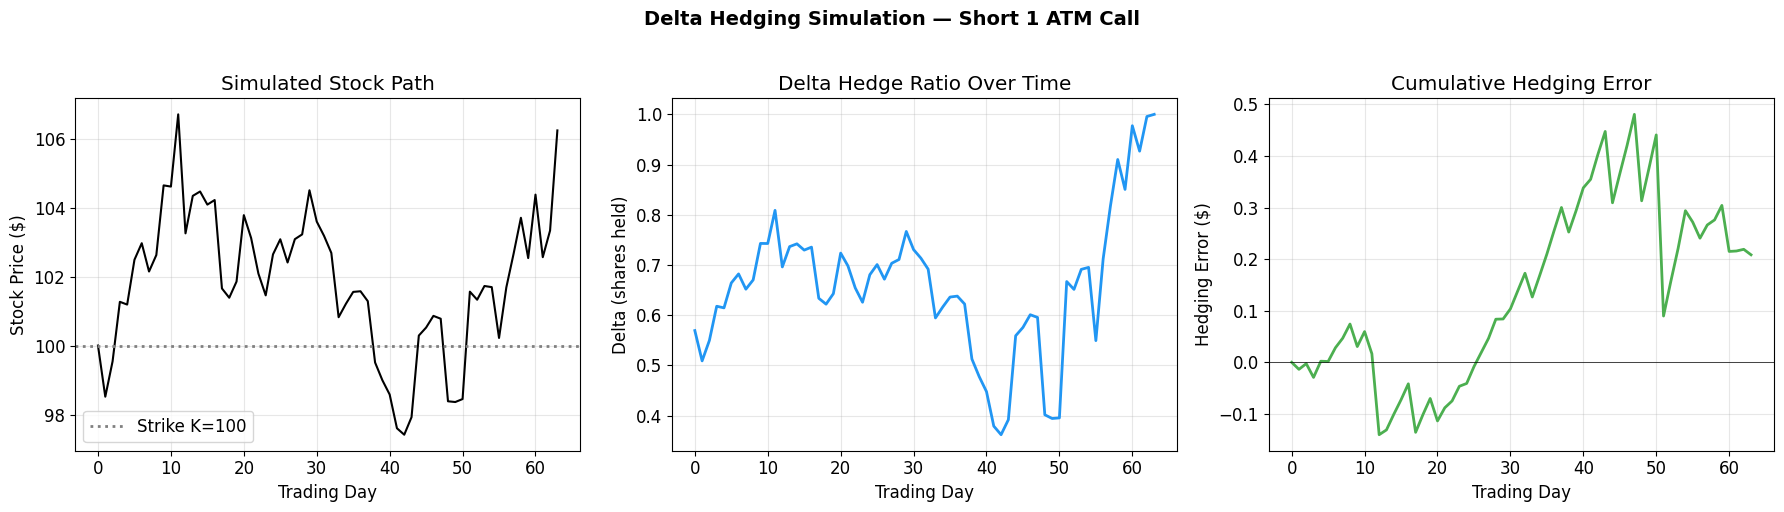

Final stock price: $106.24
Option payoff:     $6.24
Final hedge P&L:   $0.2085  (ideally ≈ 0)


In [7]:
# np.random.seed(42)
T_total = 0.25
n_steps = 63  # ~63 trading days in a quarter
dt = T_total / n_steps
K, r, sigma = 100, 0.05, 0.20

# Simulate GBM path
S_path = np.zeros(n_steps + 1)
S_path[0] = 100
for i in range(n_steps):
    dW = np.random.normal(0, np.sqrt(dt))
    S_path[i+1] = S_path[i] * np.exp((r - 0.5*sigma**2)*dt + sigma*dW)

# Delta hedge: track portfolio value
times = np.linspace(T_total, 0, n_steps + 1)
deltas = np.zeros(n_steps + 1)
hedge_pnl = np.zeros(n_steps + 1)
option_values = np.zeros(n_steps + 1)

for i in range(n_steps + 1):
    T_rem = max(times[i], 1e-6)
    bs = BlackScholes(S=S_path[i], K=K, T=T_rem, r=r, sigma=sigma)
    deltas[i] = bs.call_delta()
    option_values[i] = bs.call_price()

# Calculate hedging error
cash = option_values[0]  # premium received
shares = deltas[0]
cash -= shares * S_path[0]

hedge_errors = [0]
for i in range(1, n_steps + 1):
    cash *= np.exp(r * dt)  # interest on cash
    portfolio_value = cash + shares * S_path[i]
    hedge_error = portfolio_value - option_values[i]
    hedge_errors.append(hedge_error)
    # Rebalance
    d_shares = deltas[i] - shares
    cash -= d_shares * S_path[i]
    shares = deltas[i]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
days = np.arange(n_steps + 1)

axes[0].plot(days, S_path, color='black', linewidth=1.5)
axes[0].axhline(K, color='gray', linestyle=':', label=f'Strike K={K}')
axes[0].set_xlabel('Trading Day')
axes[0].set_ylabel('Stock Price ($)')
axes[0].set_title('Simulated Stock Path')
axes[0].legend()

axes[1].plot(days, deltas, color=CALL_COLOR)
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Delta (shares held)')
axes[1].set_title('Delta Hedge Ratio Over Time')

axes[2].plot(days, hedge_errors, color=ACCENT_COLOR)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_xlabel('Trading Day')
axes[2].set_ylabel('Hedging Error ($)')
axes[2].set_title('Cumulative Hedging Error')

plt.suptitle('Delta Hedging Simulation — Short 1 ATM Call', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

payoff = max(S_path[-1] - K, 0)
final_pnl = cash + shares * S_path[-1] - payoff
print(f"Final stock price: ${S_path[-1]:.2f}")
print(f"Option payoff:     ${payoff:.2f}")
print(f"Final hedge P&L:   ${final_pnl:.4f}  (ideally ≈ 0)")

---
## 3. Gamma ($\Gamma$) — Rate of Change of Delta <a id='3-gamma'></a>

### Derivation

Gamma is the second derivative of the option price with respect to $S$, or equivalently, the first derivative of delta:

$$\Gamma = \frac{\partial^2 V}{\partial S^2} = \frac{\partial \Delta}{\partial S} = \frac{n(d_1)}{S \sigma \sqrt{T}}$$

where $n(\cdot)$ is the standard normal PDF. Gamma is **identical for calls and puts** (from put-call parity).

### Why Gamma Matters

- **Hedging cost:** High gamma means delta changes rapidly → more frequent rebalancing → higher transaction costs.
- **P&L convexity:** Long gamma positions profit from large moves in either direction. Short gamma positions lose.
- **Taylor expansion:** $\Delta V \approx \Delta \cdot \Delta S + \frac{1}{2} \Gamma \cdot (\Delta S)^2$

The $\frac{1}{2}\Gamma(\Delta S)^2$ term is always positive for long options — this is the "convexity advantage."

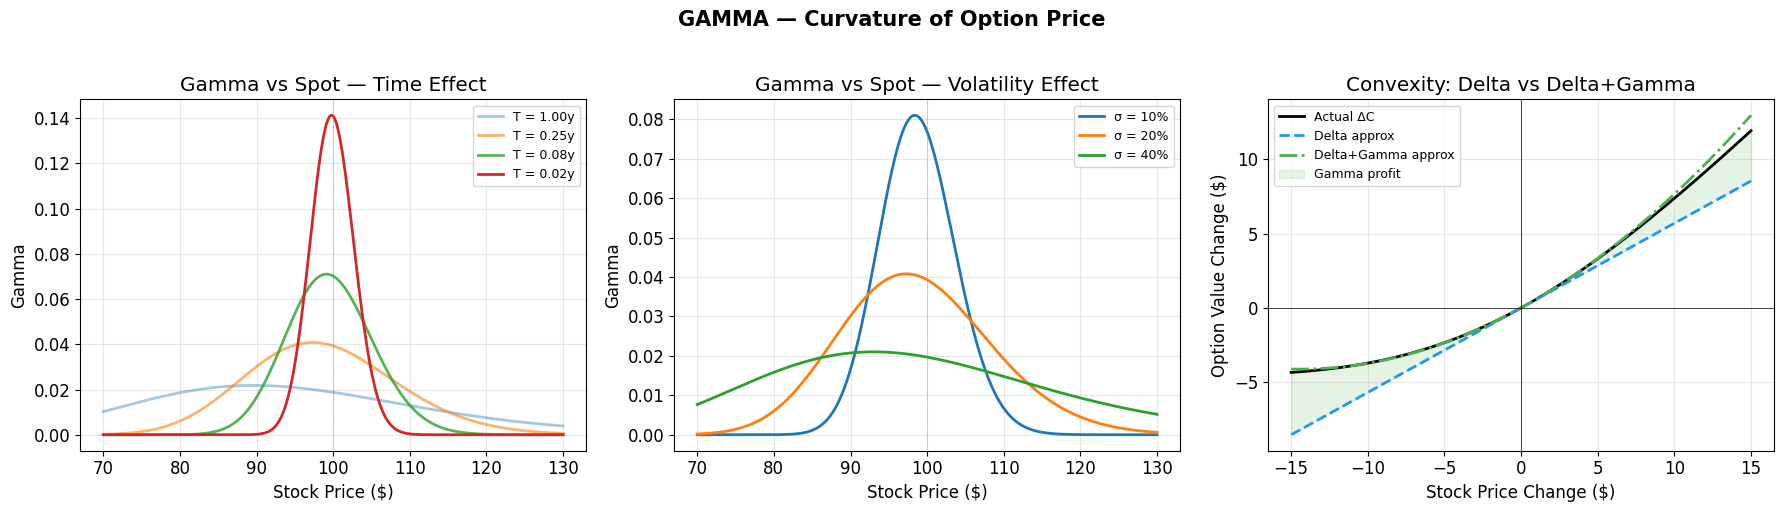

In [8]:
S_range = np.linspace(70, 130, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Gamma vs spot for different T
ax = axes[0]
for T, alpha in [(1.0, 0.4), (0.25, 0.6), (0.08, 0.8), (0.02, 1.0)]:
    bs = BlackScholes(S=S_range, K=100, T=T, r=0.05, sigma=0.20)
    ax.plot(S_range, bs.gamma(), label=f'T = {T:.2f}y', alpha=alpha)
ax.axvline(100, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Stock Price ($)')
ax.set_ylabel('Gamma')
ax.set_title('Gamma vs Spot — Time Effect')
ax.legend(fontsize=9)
ax.annotate('Gamma spikes near\nexpiry at the strike', xy=(100, 0.15),
            xytext=(115, 0.12), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black'))

# Panel 2: Gamma vs spot for different σ
ax = axes[1]
for sigma in [0.10, 0.20, 0.40]:
    bs = BlackScholes(S=S_range, K=100, T=0.25, r=0.05, sigma=sigma)
    ax.plot(S_range, bs.gamma(), label=f'σ = {sigma:.0%}')
ax.axvline(100, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Stock Price ($)')
ax.set_ylabel('Gamma')
ax.set_title('Gamma vs Spot — Volatility Effect')
ax.legend(fontsize=9)

# Panel 3: Dollar gamma P&L — the convexity advantage
ax = axes[2]
dS_range = np.linspace(-15, 15, 300)
bs_atm = BlackScholes(S=100, K=100, T=0.25, r=0.05, sigma=0.20)
delta_0 = bs_atm.call_delta()
gamma_0 = bs_atm.gamma()
price_0 = bs_atm.call_price()

# Actual vs linear (delta-only) vs quadratic (delta+gamma) approximation
actual_prices = BlackScholes(S=100+dS_range, K=100, T=0.25, r=0.05, sigma=0.20).call_price()
linear_approx = price_0 + delta_0 * dS_range
quad_approx = price_0 + delta_0 * dS_range + 0.5 * gamma_0 * dS_range**2

ax.plot(dS_range, actual_prices - price_0, 'k-', label='Actual ΔC', linewidth=2)
ax.plot(dS_range, linear_approx - price_0, '--', color=CALL_COLOR, label='Delta approx')
ax.plot(dS_range, quad_approx - price_0, '-.', color=ACCENT_COLOR, label='Delta+Gamma approx')
ax.fill_between(dS_range, linear_approx - price_0, actual_prices - price_0,
                alpha=0.15, color=ACCENT_COLOR, label='Gamma profit')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Stock Price Change ($)')
ax.set_ylabel('Option Value Change ($)')
ax.set_title('Convexity: Delta vs Delta+Gamma')
ax.legend(fontsize=9)

plt.suptitle('GAMMA — Curvature of Option Price', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Gamma Scalping: The Theta-Gamma Tradeoff

One of the most important relationships in options: **long gamma costs theta, short gamma earns theta.**

If you're delta-hedged and long gamma, you profit from realized moves but bleed time decay. The breakeven daily move is:

$$|\Delta S|_{\text{breakeven}} = \sqrt{\frac{2|\Theta|}{\Gamma}}$$

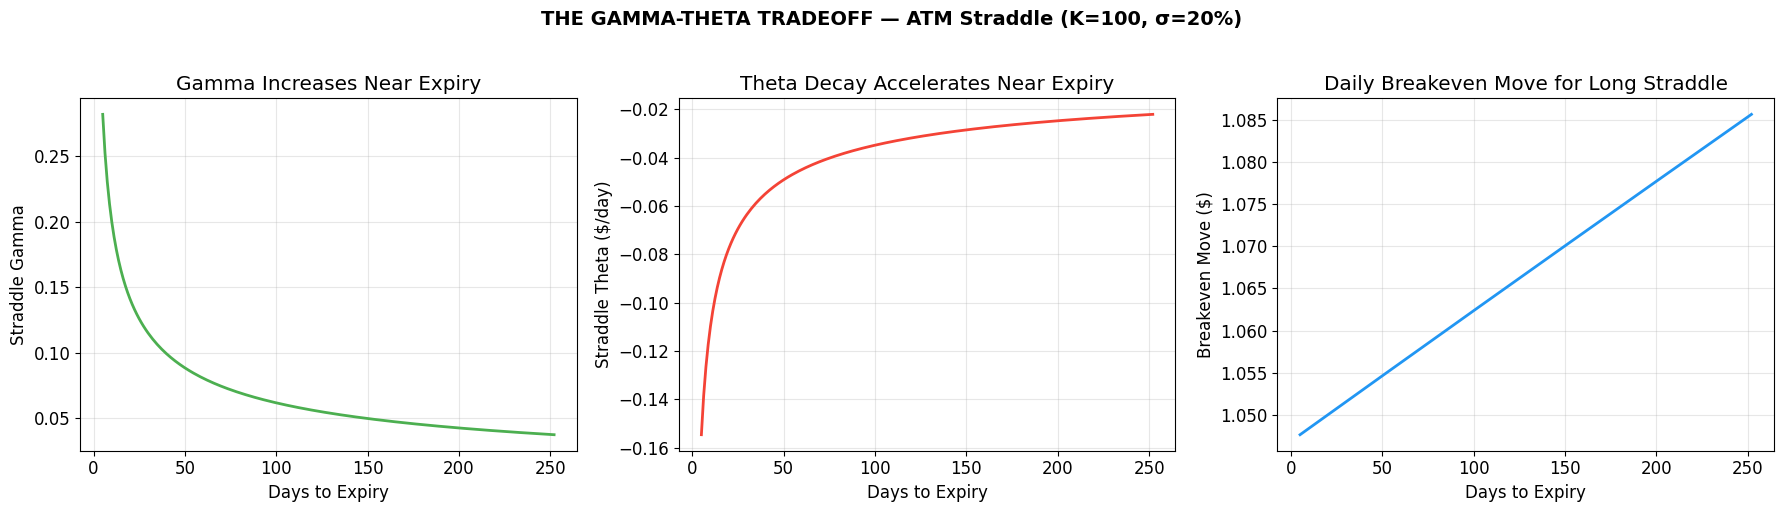

30-DTE ATM Straddle:
  Gamma:  0.1385 ($/dollar²)
  Theta:  $-0.0763/day
  Breakeven daily move: $1.05 (1.1% of spot)


In [10]:
# Show the gamma-theta tradeoff for an ATM straddle
T_range = np.linspace(0.02, 1.0, 200)
gammas, thetas, breakevens = [], [], []

for T in T_range:
    bs = BlackScholes(S=100, K=100, T=T, r=0.05, sigma=0.20)
    g = bs.gamma()
    t = bs.call_theta() + bs.put_theta()  # straddle theta
    gammas.append(g * 2)  # straddle = 2x single gamma
    thetas.append(t)
    breakevens.append(np.sqrt(2 * abs(t) / (g * 2)) if g > 0 else 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(T_range * 252, gammas, color=ACCENT_COLOR)
axes[0].set_xlabel('Days to Expiry')
axes[0].set_ylabel('Straddle Gamma')
axes[0].set_title('Gamma Increases Near Expiry')

axes[1].plot(T_range * 252, thetas, color=PUT_COLOR)
axes[1].set_xlabel('Days to Expiry')
axes[1].set_ylabel('Straddle Theta ($/day)')
axes[1].set_title('Theta Decay Accelerates Near Expiry')

axes[2].plot(T_range * 252, breakevens, color=CALL_COLOR)
axes[2].set_xlabel('Days to Expiry')
axes[2].set_ylabel('Breakeven Move ($)')
axes[2].set_title('Daily Breakeven Move for Long Straddle')

plt.suptitle('THE GAMMA-THETA TRADEOFF — ATM Straddle (K=100, σ=20%)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Numerical example
bs = BlackScholes(S=100, K=100, T=30/365, r=0.05, sigma=0.20)
g = bs.gamma() * 2
t = bs.call_theta() + bs.put_theta()
be = np.sqrt(2 * abs(t) / g)
print("30-DTE ATM Straddle:")
print(f"  Gamma:  {g:.4f} ($/dollar²)")
print(f"  Theta:  ${t:.4f}/day")
print(f"  Breakeven daily move: ${be:.2f} ({be/100:.1%} of spot)")

---
## 4. Theta ($\Theta$) — Time Decay <a id='4-theta'></a>

### Derivation

Theta measures the rate of change of the option price as time passes (with all else constant):

$$\Theta_{\text{call}} = -\frac{S \, n(d_1) \, \sigma}{2\sqrt{T}} - r K e^{-rT} N(d_2)$$

$$\Theta_{\text{put}} = -\frac{S \, n(d_1) \, \sigma}{2\sqrt{T}} + r K e^{-rT} N(-d_2)$$

The first term (always negative) is the **diffusion component** — as time shrinks, there's less chance for the option to gain value. The second term is the **drift component** from the risk-free rate.

### Key Insights
- Theta is almost always **negative** for long options (time works against you).
- ATM options have the **highest** theta in absolute value.
- Theta accelerates as expiry approaches (the "$\sqrt{T}$" in the denominator).

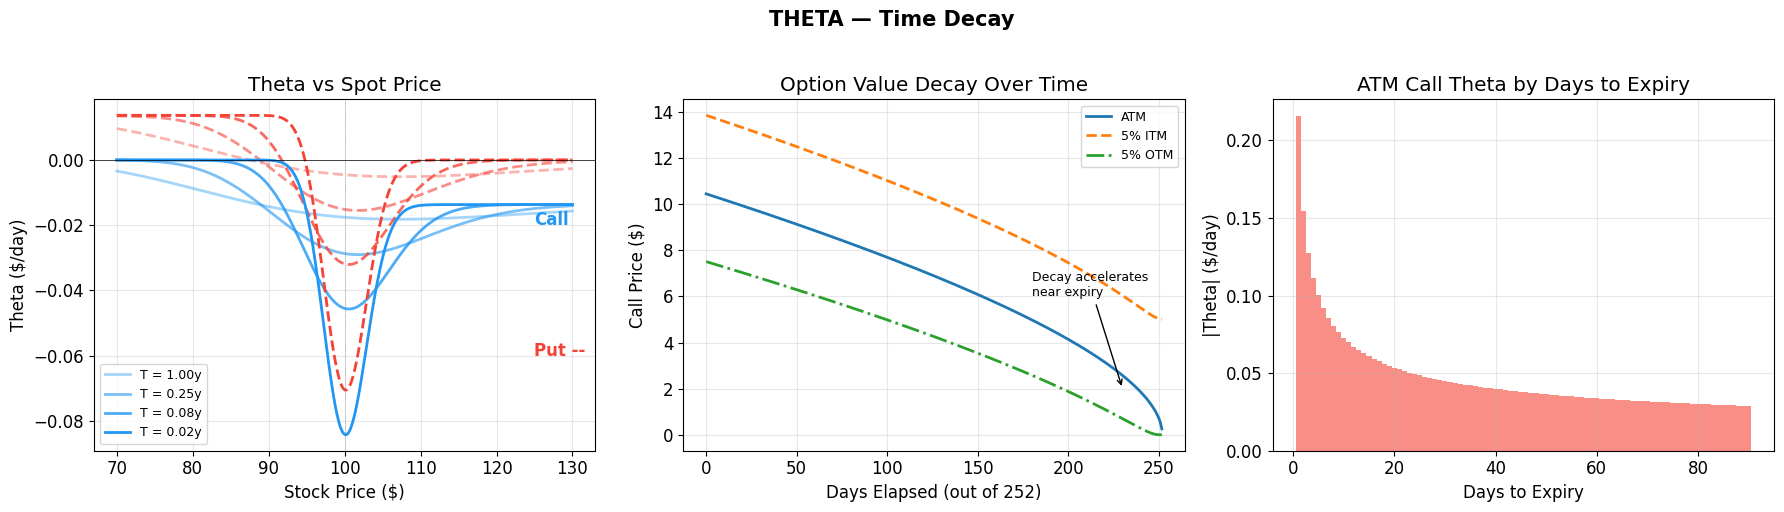

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Theta vs spot for different T
ax = axes[0]
S_range = np.linspace(70, 130, 500)
for T, alpha in [(1.0, 0.4), (0.25, 0.6), (0.08, 0.8), (0.02, 1.0)]:
    bs = BlackScholes(S=S_range, K=100, T=T, r=0.05, sigma=0.20)
    ax.plot(S_range, bs.call_theta(), label=f'T = {T:.2f}y', alpha=alpha, color=CALL_COLOR)
    ax.plot(S_range, bs.put_theta(), alpha=alpha, color=PUT_COLOR, linestyle='--')
ax.axvline(100, color='gray', linewidth=0.5, linestyle=':')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Stock Price ($)')
ax.set_ylabel('Theta ($/day)')
ax.set_title('Theta vs Spot Price')
ax.legend(fontsize=9)
ax.text(125, -0.02, 'Call', color=CALL_COLOR, fontweight='bold')
ax.text(125, -0.06, 'Put --', color=PUT_COLOR, fontweight='bold')

# Panel 2: Option value decay over time
ax = axes[1]
T_range = np.linspace(1.0, 0.001, 300)
for moneyness, label, ls in [(100, 'ATM', '-'), (105, '5% ITM', '--'), (95, '5% OTM', '-.')]:
    prices = [BlackScholes(S=moneyness, K=100, T=T, r=0.05, sigma=0.20).call_price() for T in T_range]
    ax.plot((1.0 - T_range) * 252, prices, ls, label=label)
ax.set_xlabel('Days Elapsed (out of 252)')
ax.set_ylabel('Call Price ($)')
ax.set_title('Option Value Decay Over Time')
ax.legend(fontsize=9)
ax.annotate('Decay accelerates\nnear expiry', xy=(230, 2), xytext=(180, 6),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

# Panel 3: "Weekend effect" — theta for different DTE
ax = axes[2]
dte_range = np.arange(1, 91)
atm_thetas = []
for dte in dte_range:
    bs = BlackScholes(S=100, K=100, T=dte/365, r=0.05, sigma=0.20)
    atm_thetas.append(bs.call_theta())
ax.bar(dte_range, [-t for t in atm_thetas], color=PUT_COLOR, alpha=0.6, width=1.0)
ax.set_xlabel('Days to Expiry')
ax.set_ylabel('|Theta| ($/day)')
ax.set_title('ATM Call Theta by Days to Expiry')

plt.suptitle('THETA — Time Decay', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Vega ($\nu$) — Sensitivity to Volatility <a id='5-vega'></a>

### Derivation

Vega measures sensitivity to implied volatility. Despite the Greek letter convention, vega is not actually a Greek letter — it's universally used anyway.

$$\nu = \frac{\partial V}{\partial \sigma} = S \, n(d_1) \sqrt{T}$$

Vega is **identical for calls and puts** (put-call parity again — the difference $C - P$ doesn't depend on $\sigma$).

We report vega per 1 percentage point change in volatility (dividing by 100).

### Key Properties
- Always positive for long options (higher vol → higher option value).
- Peaks for ATM options.
- Increases with time to expiry (more time = more exposure to vol changes).
- Proportional to $S \sqrt{T}$ — larger and longer-dated options have more vega.

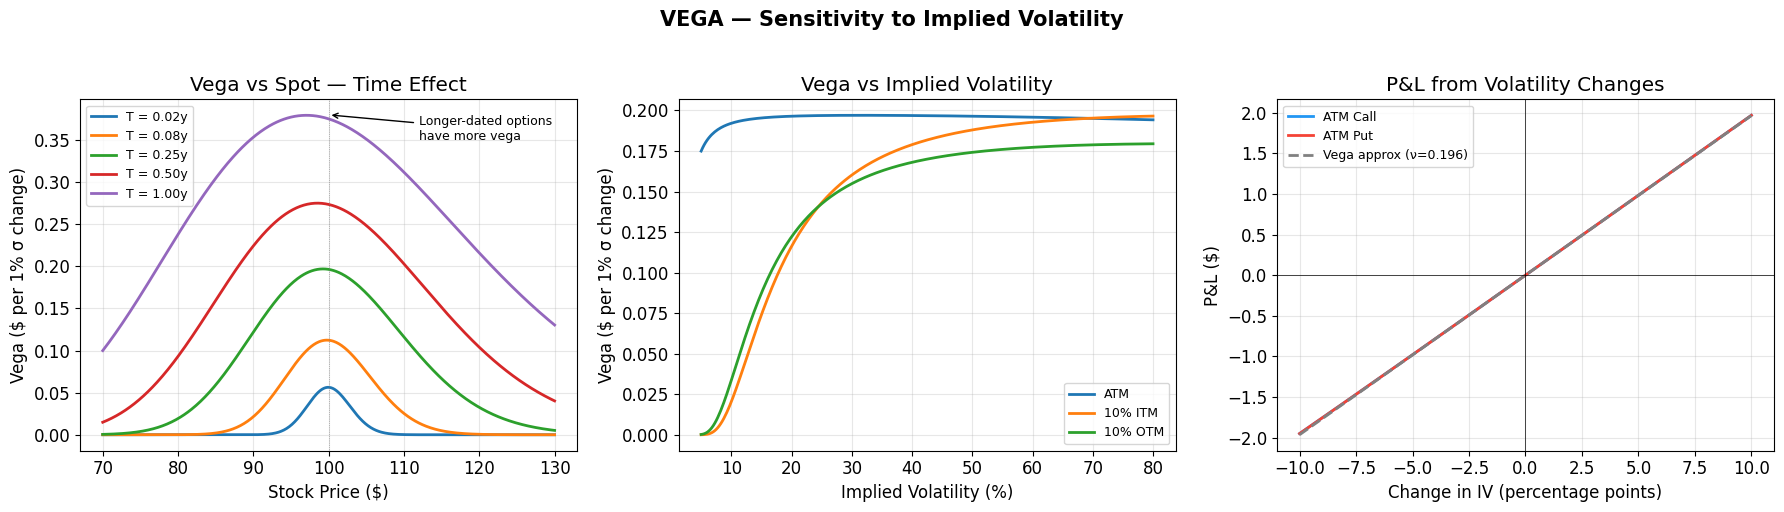

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
S_range = np.linspace(70, 130, 500)

# Panel 1: Vega vs spot for different T
ax = axes[0]
for T in [0.02, 0.08, 0.25, 0.5, 1.0]:
    bs = BlackScholes(S=S_range, K=100, T=T, r=0.05, sigma=0.20)
    ax.plot(S_range, bs.vega(), label=f'T = {T:.2f}y')
ax.axvline(100, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Stock Price ($)')
ax.set_ylabel('Vega ($ per 1% σ change)')
ax.set_title('Vega vs Spot — Time Effect')
ax.legend(fontsize=9)
ax.annotate('Longer-dated options\nhave more vega', xy=(100, 0.38),
            xytext=(112, 0.35), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black'))

# Panel 2: Vega vs implied vol
ax = axes[1]
sigma_range = np.linspace(0.05, 0.80, 300)
for moneyness, label in [(100, 'ATM'), (110, '10% ITM'), (90, '10% OTM')]:
    vegas = [BlackScholes(S=moneyness, K=100, T=0.25, r=0.05, sigma=s).vega() for s in sigma_range]
    ax.plot(sigma_range * 100, vegas, label=label)
ax.set_xlabel('Implied Volatility (%)')
ax.set_ylabel('Vega ($ per 1% σ change)')
ax.set_title('Vega vs Implied Volatility')
ax.legend(fontsize=9)

# Panel 3: P&L from a vol change
ax = axes[2]
vol_changes = np.linspace(-10, 10, 200)  # in percentage points
base_sigma = 0.20
for moneyness, label, color in [(100, 'ATM Call', CALL_COLOR), (100, 'ATM Put', PUT_COLOR)]:
    base = BlackScholes(S=100, K=100, T=0.25, r=0.05, sigma=base_sigma)
    base_price = base.call_price() if 'Call' in label else base.put_price()
    pnls = []
    for dv in vol_changes:
        new_bs = BlackScholes(S=100, K=100, T=0.25, r=0.05, sigma=base_sigma + dv/100)
        new_price = new_bs.call_price() if 'Call' in label else new_bs.put_price()
        pnls.append(new_price - base_price)
    ax.plot(vol_changes, pnls, label=label, color=color)

# Linear approximation using vega
vega_val = base.vega()
ax.plot(vol_changes, vega_val * vol_changes, '--', color='gray', label=f'Vega approx (ν={vega_val:.3f})')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Change in IV (percentage points)')
ax.set_ylabel('P&L ($)')
ax.set_title('P&L from Volatility Changes')
ax.legend(fontsize=9)

plt.suptitle('VEGA — Sensitivity to Implied Volatility', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Rho ($\rho$) — Sensitivity to Interest Rates <a id='6-rho'></a>

### Derivation

Rho measures sensitivity to the risk-free interest rate:

$$\rho_{\text{call}} = K T e^{-rT} N(d_2)$$

$$\rho_{\text{put}} = -K T e^{-rT} N(-d_2)$$

We report per 1 percentage point change in $r$.

### Intuition

Higher rates → lower present value of the strike → calls are worth more, puts are worth less. Rho is typically the smallest Greek for short-dated options but can matter significantly for LEAPS (long-dated options).

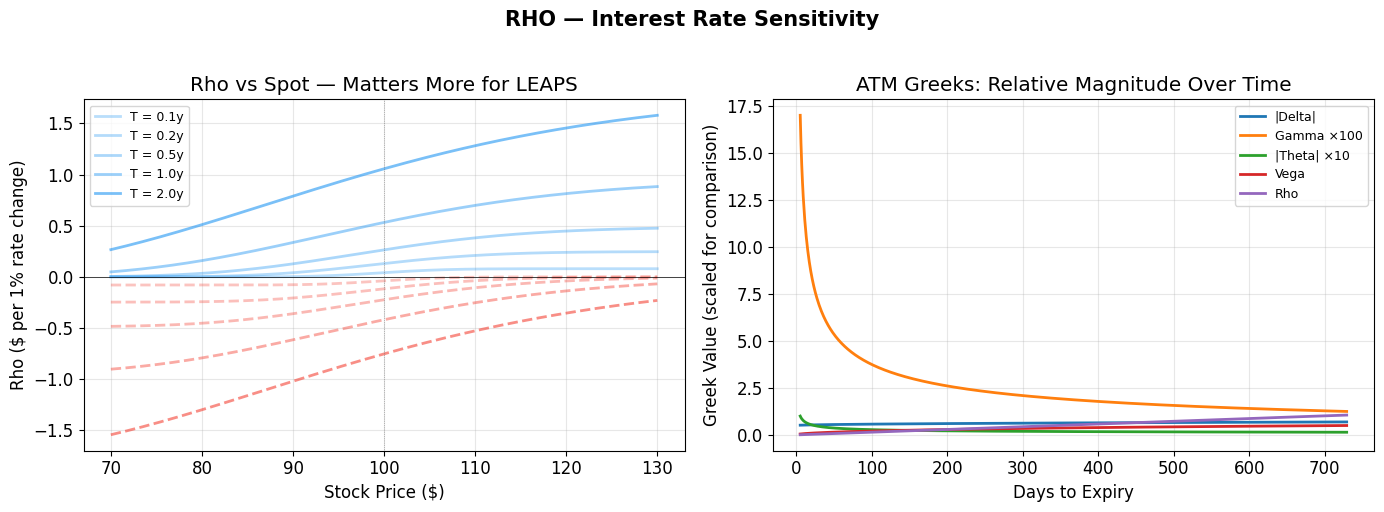

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
S_range = np.linspace(70, 130, 500)

# Panel 1: Rho vs spot for different T
ax = axes[0]
for T in [0.08, 0.25, 0.5, 1.0, 2.0]:
    bs = BlackScholes(S=S_range, K=100, T=T, r=0.05, sigma=0.20)
    ax.plot(S_range, bs.call_rho(), label=f'T = {T:.1f}y', color=CALL_COLOR, alpha=0.3 + 0.15*T)
    ax.plot(S_range, bs.put_rho(), linestyle='--', color=PUT_COLOR, alpha=0.3 + 0.15*T)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(100, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Stock Price ($)')
ax.set_ylabel('Rho ($ per 1% rate change)')
ax.set_title('Rho vs Spot — Matters More for LEAPS')
ax.legend(fontsize=9)

# Panel 2: Relative magnitude of all Greeks
ax = axes[1]
T_range_days = np.arange(5, 365*2)
deltas, gammas, thetas, vegas, rhos = [], [], [], [], []
for dte in T_range_days:
    bs = BlackScholes(S=100, K=100, T=dte/365, r=0.05, sigma=0.20)
    deltas.append(abs(bs.call_delta()))
    gammas.append(bs.gamma() * 100)  # scale for visibility
    thetas.append(abs(bs.call_theta()) * 10)
    vegas.append(bs.vega())
    rhos.append(bs.call_rho())

ax.plot(T_range_days, deltas, label='|Delta|')
ax.plot(T_range_days, gammas, label='Gamma ×100')
ax.plot(T_range_days, thetas, label='|Theta| ×10')
ax.plot(T_range_days, vegas, label='Vega')
ax.plot(T_range_days, rhos, label='Rho')
ax.set_xlabel('Days to Expiry')
ax.set_ylabel('Greek Value (scaled for comparison)')
ax.set_title('ATM Greeks: Relative Magnitude Over Time')
ax.legend(fontsize=9)

plt.suptitle('RHO — Interest Rate Sensitivity', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Greeks in Action: Portfolio Analysis <a id='7-greeks-in-action'></a>

Greeks are additive across a portfolio. Let's analyze some common multi-leg strategies and see how their aggregate Greeks shape the risk profile.

In [14]:
def portfolio_greeks(positions, S_range, T=0.25, r=0.05, sigma=0.20):
    """Compute aggregate Greeks for a portfolio of options.
    positions: list of (qty, 'call'/'put', strike)
    """
    agg = {'delta': np.zeros_like(S_range, dtype=float),
           'gamma': np.zeros_like(S_range, dtype=float),
           'theta': np.zeros_like(S_range, dtype=float),
           'vega': np.zeros_like(S_range, dtype=float),
           'value': np.zeros_like(S_range, dtype=float)}

    for qty, opt_type, strike in positions:
        bs = BlackScholes(S=S_range, K=strike, T=T, r=r, sigma=sigma)
        if opt_type == 'call':
            agg['delta'] += qty * bs.call_delta()
            agg['theta'] += qty * bs.call_theta()
            agg['value'] += qty * bs.call_price()
        else:
            agg['delta'] += qty * bs.put_delta()
            agg['theta'] += qty * bs.put_theta()
            agg['value'] += qty * bs.put_price()
        agg['gamma'] += qty * bs.gamma()
        agg['vega'] += qty * bs.vega()

    return agg


def plot_strategy(name, positions, S_range):
    greeks = portfolio_greeks(positions, S_range)

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    labels = ['value', 'delta', 'gamma', 'theta', 'vega']
    titles = ['Position Value ($)', 'Delta', 'Gamma', 'Theta ($/day)', 'Vega ($/1% σ)']

    for ax, key, title in zip(axes, labels, titles):
        color = CALL_COLOR if np.mean(greeks[key]) >= 0 else PUT_COLOR
        ax.plot(S_range, greeks[key], color=color)
        ax.fill_between(S_range, 0, greeks[key], alpha=0.1, color=color)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.axvline(100, color='gray', linewidth=0.5, linestyle=':')
        ax.set_xlabel('Stock Price ($)', fontsize=9)
        ax.set_title(title, fontsize=10)

    # Mark strikes
    strikes = set(k for _, _, k in positions)
    for ax in axes:
        for k in strikes:
            ax.axvline(k, color='orange', linewidth=0.5, linestyle='--', alpha=0.5)

    pos_str = ', '.join(f'{q:+d} {t[0].upper()}{k}' for q, t, k in positions)
    fig.suptitle(f'{name}: {pos_str}', fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


S_range = np.linspace(70, 130, 500)

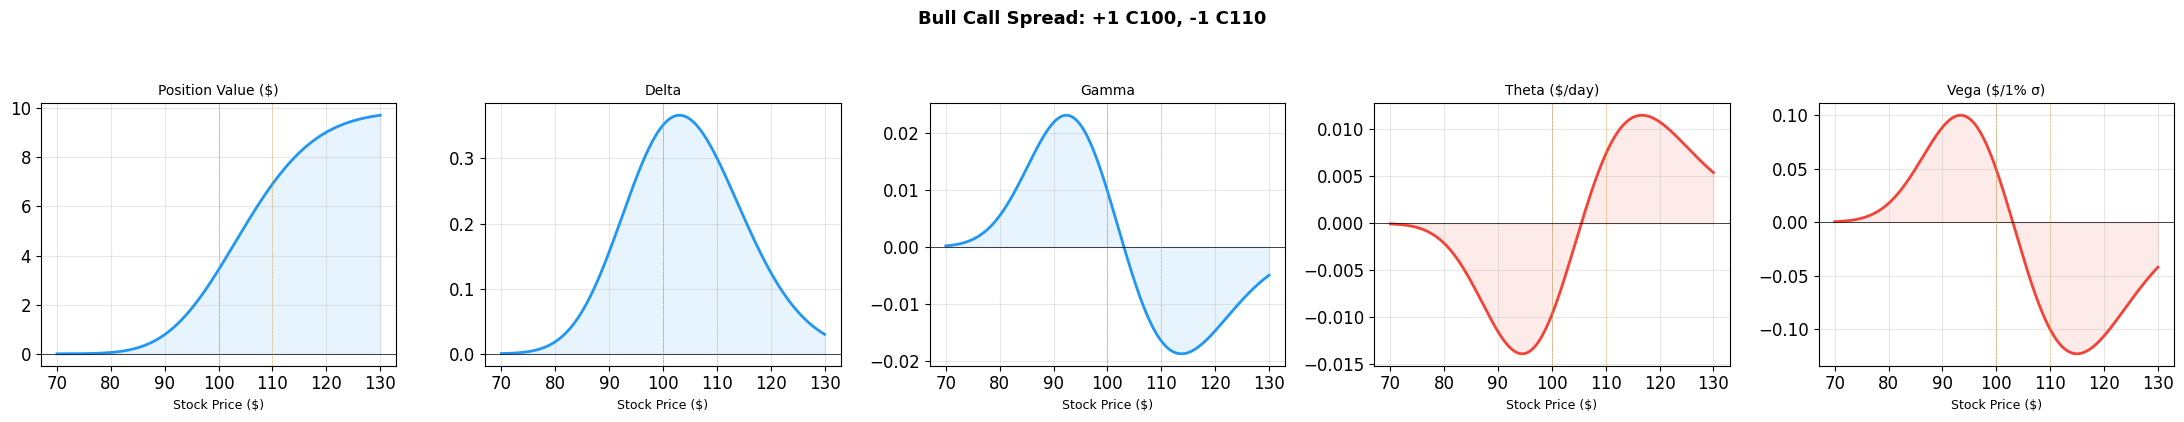

In [15]:
# Bull Call Spread: +1 C100, -1 C110
plot_strategy('Bull Call Spread', [(+1, 'call', 100), (-1, 'call', 110)], S_range)

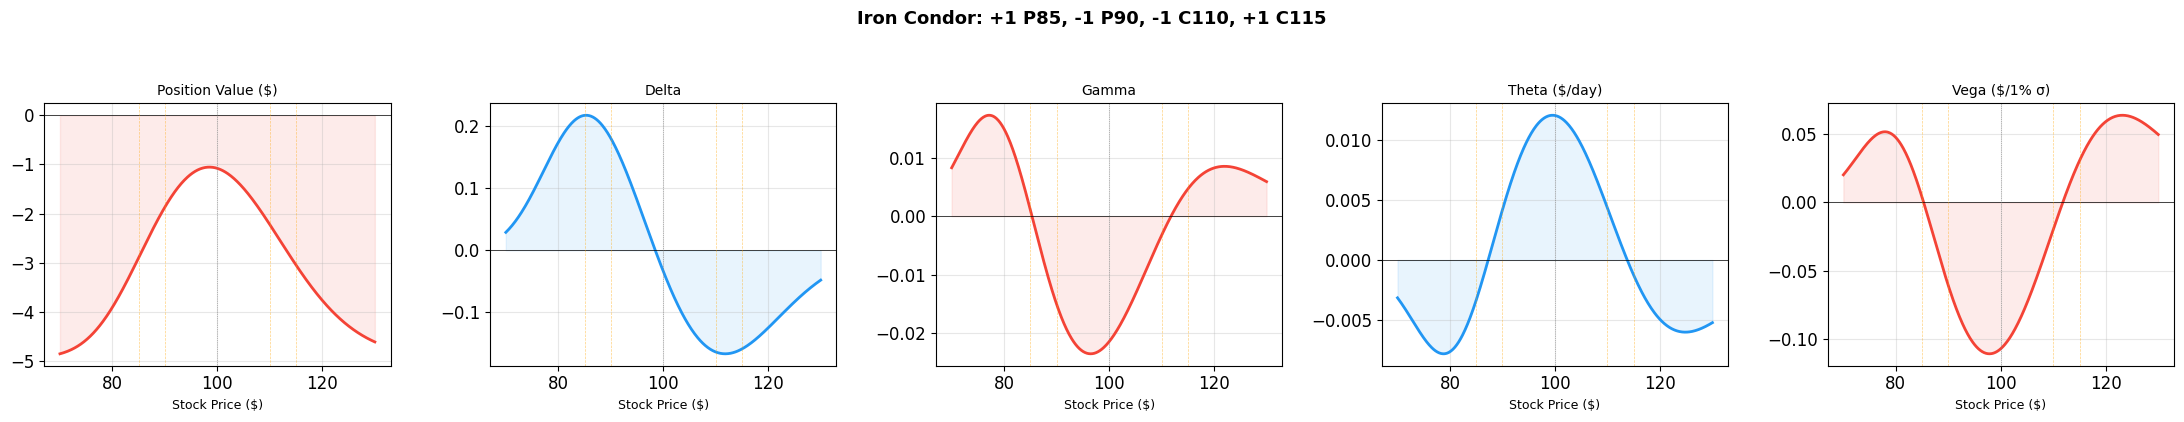

In [16]:
# Iron Condor: +1 P85, -1 P90, -1 C110, +1 C115
plot_strategy('Iron Condor', [
    (+1, 'put', 85), (-1, 'put', 90),
    (-1, 'call', 110), (+1, 'call', 115)
], S_range)

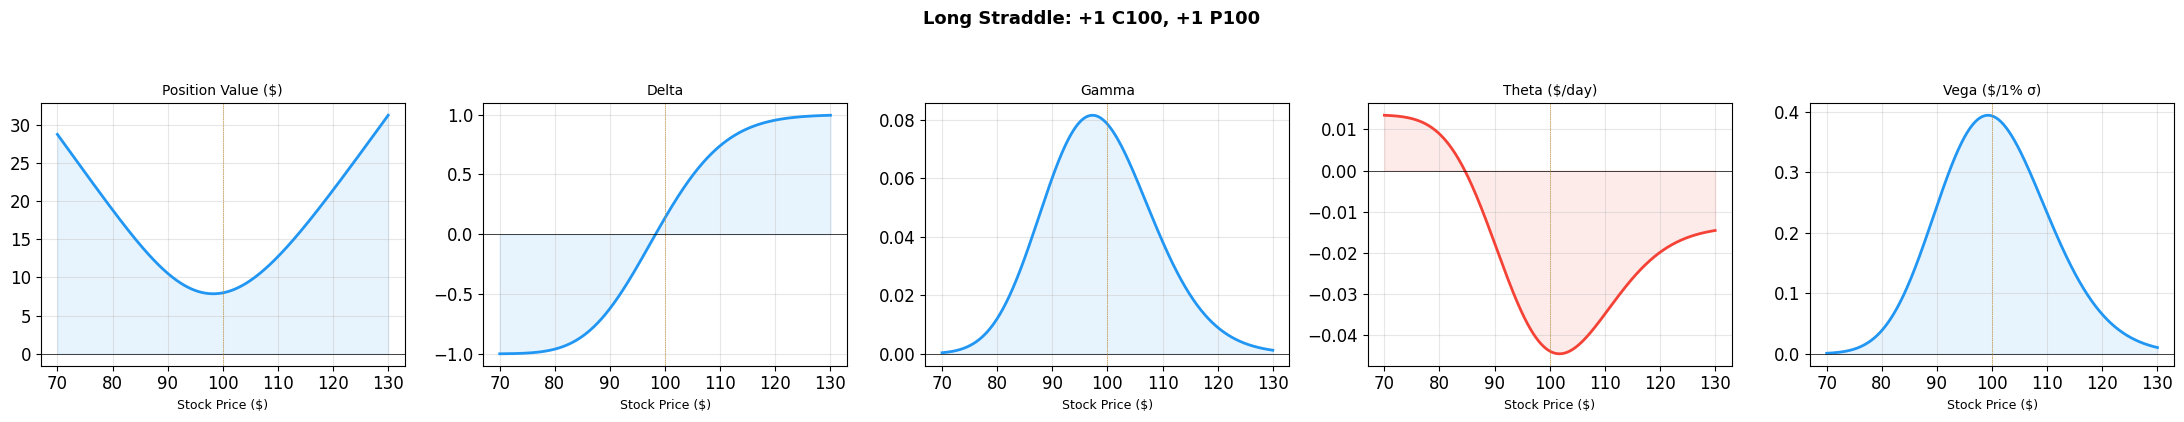

In [17]:
# Straddle: +1 C100, +1 P100
plot_strategy('Long Straddle', [(+1, 'call', 100), (+1, 'put', 100)], S_range)

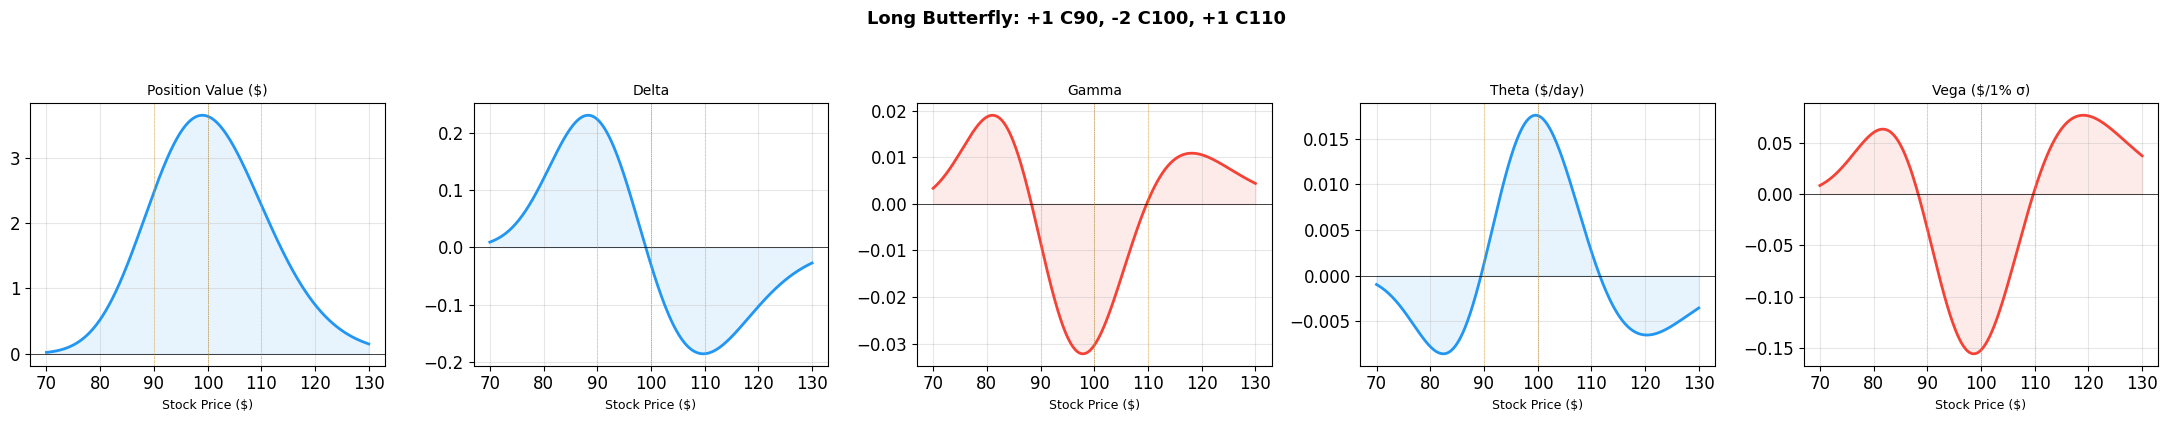

In [18]:
# Butterfly: +1 C90, -2 C100, +1 C110
plot_strategy('Long Butterfly', [
    (+1, 'call', 90), (-2, 'call', 100), (+1, 'call', 110)
], S_range)

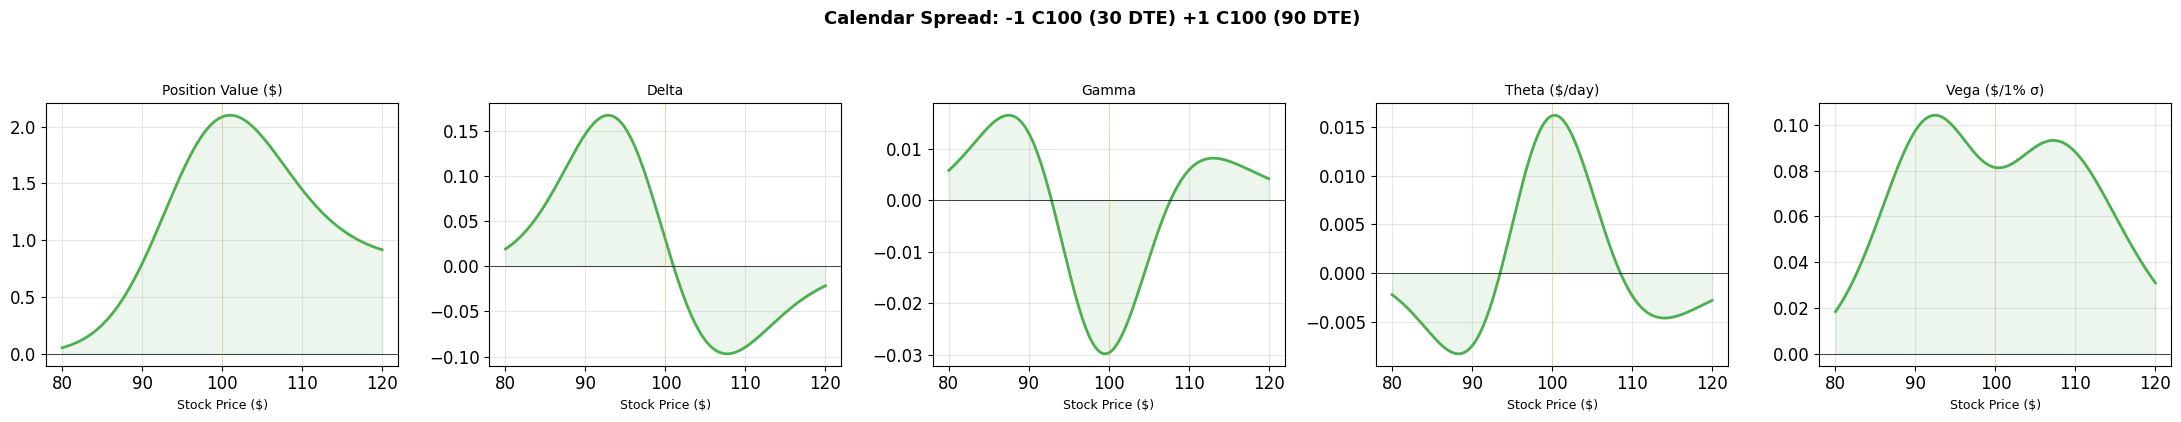

In [19]:
# Calendar Spread (approximated with different T)
S_range_cal = np.linspace(80, 120, 500)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
labels_list = ['value', 'delta', 'gamma', 'theta', 'vega']
titles_list = ['Position Value ($)', 'Delta', 'Gamma', 'Theta ($/day)', 'Vega ($/1% σ)']

agg = {k: np.zeros_like(S_range_cal, dtype=float) for k in labels_list}

# Short front-month (30 DTE), long back-month (90 DTE)
for S_val in [S_range_cal]:
    bs_short = BlackScholes(S=S_val, K=100, T=30/365, r=0.05, sigma=0.20)
    bs_long = BlackScholes(S=S_val, K=100, T=90/365, r=0.05, sigma=0.20)

    agg['value'] = bs_long.call_price() - bs_short.call_price()
    agg['delta'] = bs_long.call_delta() - bs_short.call_delta()
    agg['gamma'] = bs_long.gamma() - bs_short.gamma()
    agg['theta'] = bs_long.call_theta() - bs_short.call_theta()
    agg['vega'] = bs_long.vega() - bs_short.vega()

for ax, key, title in zip(axes, labels_list, titles_list):
    color = ACCENT_COLOR
    ax.plot(S_range_cal, agg[key], color=color)
    ax.fill_between(S_range_cal, 0, agg[key], alpha=0.1, color=color)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(100, color='orange', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.set_xlabel('Stock Price ($)', fontsize=9)
    ax.set_title(title, fontsize=10)

fig.suptitle('Calendar Spread: -1 C100 (30 DTE) +1 C100 (90 DTE)', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 8. Greek Surfaces: 3D Visualization <a id='8-greek-surfaces'></a>

Let's see how each Greek varies simultaneously across both stock price and time to expiry.

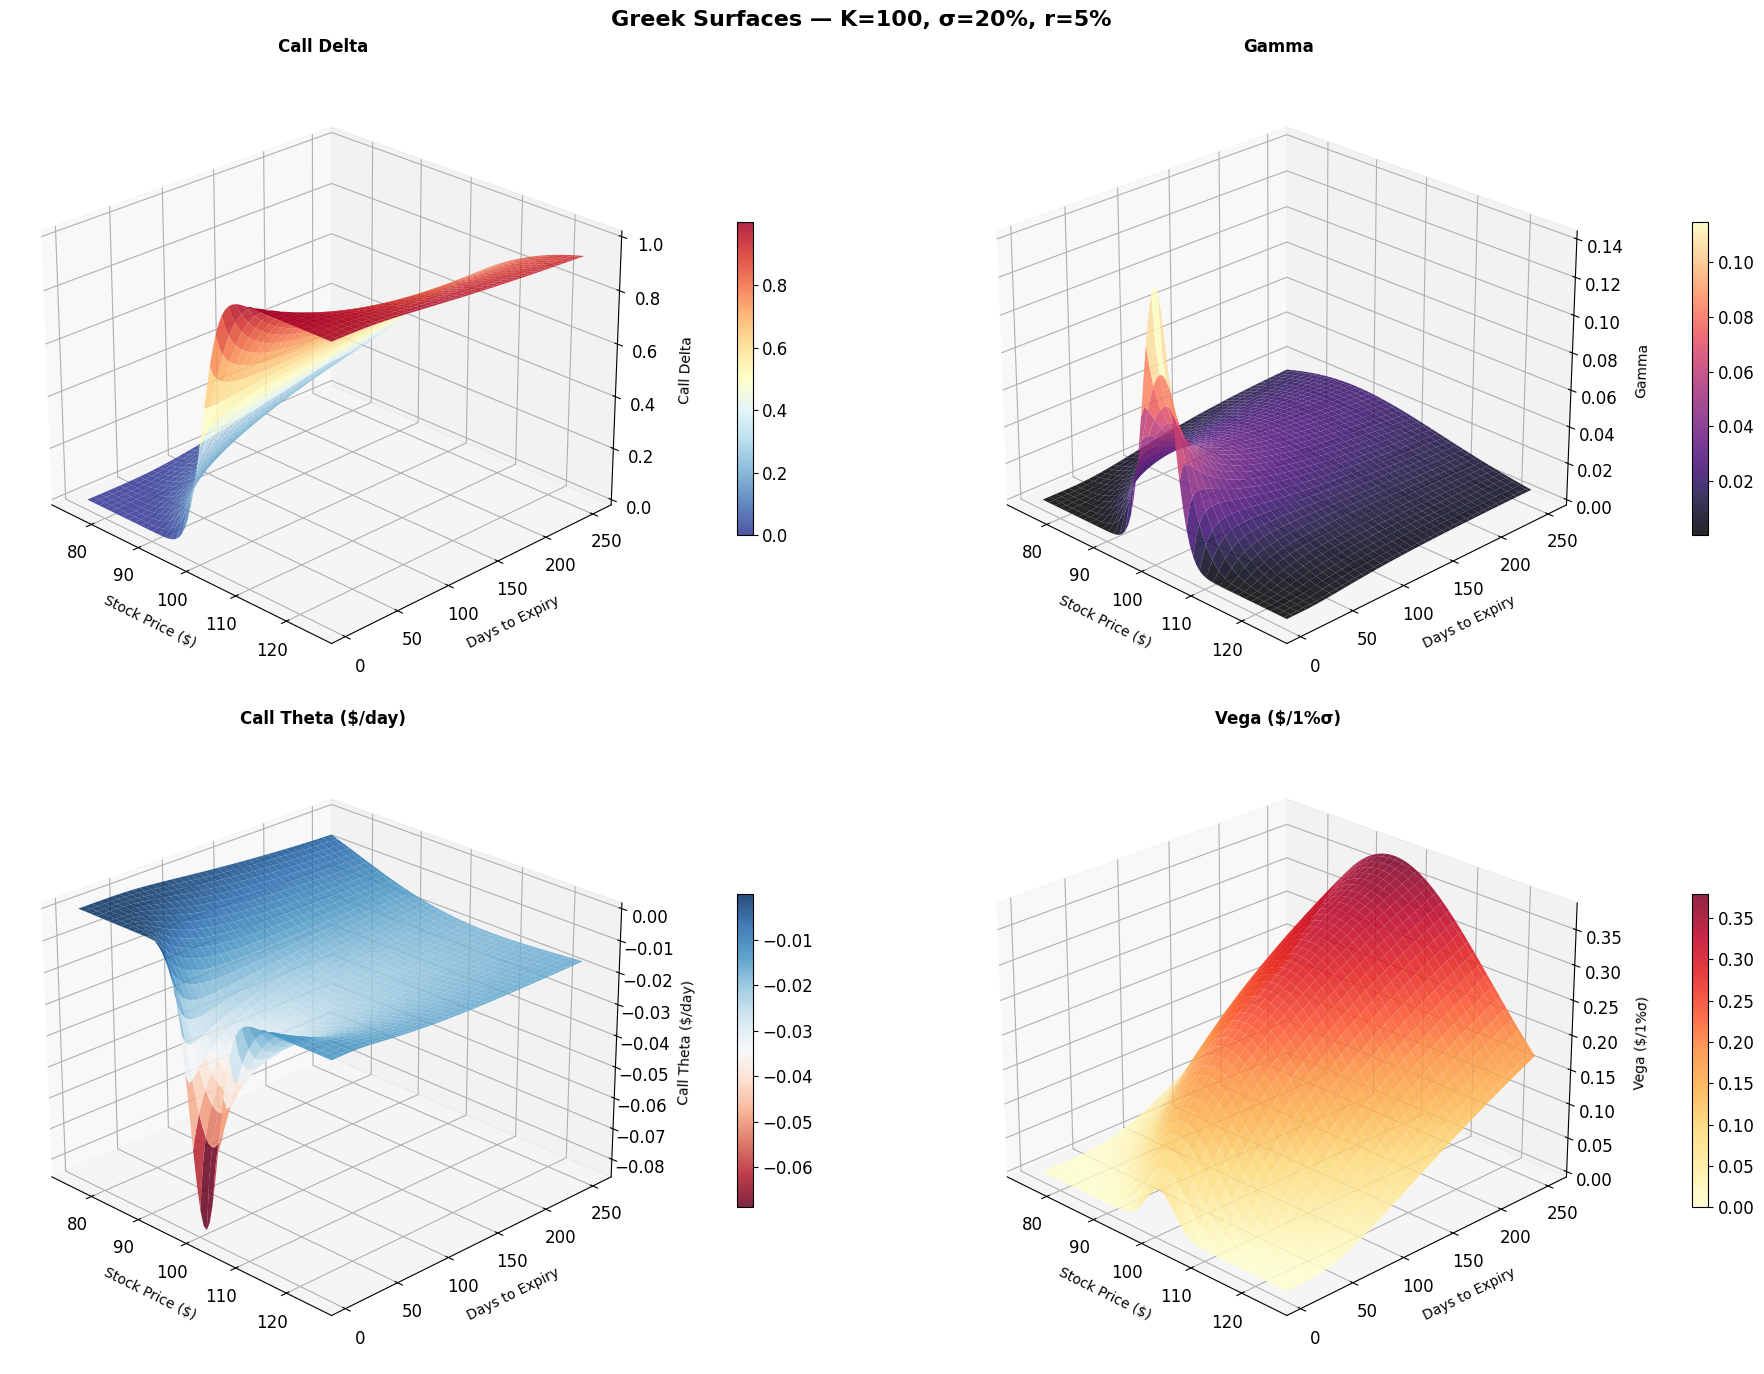

In [20]:
S_surf = np.linspace(75, 125, 80)
T_surf = np.linspace(0.02, 1.0, 80)
S_grid, T_grid = np.meshgrid(S_surf, T_surf)

bs_surf = BlackScholes(S=S_grid, K=100, T=T_grid, r=0.05, sigma=0.20)

greeks_data = {
    'Call Delta': bs_surf.call_delta(),
    'Gamma': bs_surf.gamma(),
    'Call Theta ($/day)': bs_surf.call_theta(),
    'Vega ($/1%σ)': bs_surf.vega(),
}

cmaps = ['RdYlBu_r', 'magma', 'RdBu', 'YlOrRd']

fig = plt.figure(figsize=(20, 14))

for idx, (title, data) in enumerate(greeks_data.items()):
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    surf = ax.plot_surface(S_grid, T_grid * 252, data, cmap=cmaps[idx], alpha=0.85, edgecolor='none')
    ax.set_xlabel('Stock Price ($)', fontsize=10, labelpad=8)
    ax.set_ylabel('Days to Expiry', fontsize=10, labelpad=8)
    ax.set_zlabel(title, fontsize=10, labelpad=8)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.view_init(elev=25, azim=-45)
    fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)

plt.suptitle('Greek Surfaces — K=100, σ=20%, r=5%', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

---
## 9. Practical Exercises <a id='9-exercises'></a>

### Exercise 1: Greeks Calculator

Use the `BlackScholes` class to compute all Greeks for a custom set of parameters. Modify the inputs below to explore.

In [21]:
# ---- MODIFY THESE PARAMETERS ----
S = 105      # Current stock price
K = 100      # Strike price
T = 60/365   # Time to expiry (in years)
r = 0.05     # Risk-free rate
sigma = 0.25 # Implied volatility
# ----------------------------------

bs = BlackScholes(S=S, K=K, T=T, r=r, sigma=sigma)

print(f"{'='*55}")
print("  Black-Scholes Options Calculator")
print(f"{'='*55}")
print(f"  S = ${S:.2f}  |  K = ${K:.2f}  |  T = {T*365:.0f} days")
print(f"  r = {r:.2%}   |  σ = {sigma:.2%}")
print(f"  Moneyness: S/K = {S/K:.4f} ({'ITM' if S>K else 'OTM' if S<K else 'ATM'} call)")
print(f"{'='*55}")
print(f"{'':>22} {'CALL':>12} {'PUT':>12}")
print(f"{'-'*55}")
print(f"  {'Price':>20} ${bs.call_price():>11.4f} ${bs.put_price():>11.4f}")
print(f"  {'Delta':>20} {bs.call_delta():>12.4f} {bs.put_delta():>12.4f}")
print(f"  {'Gamma':>20} {bs.gamma():>12.4f} {bs.gamma():>12.4f}")
print(f"  {'Theta ($/day)':>20} {bs.call_theta():>12.4f} {bs.put_theta():>12.4f}")
print(f"  {'Vega ($/1% σ)':>20} {bs.vega():>12.4f} {bs.vega():>12.4f}")
print(f"  {'Rho ($/1% r)':>20} {bs.call_rho():>12.4f} {bs.put_rho():>12.4f}")
print(f"{'='*55}")
print(f"\n  Put-Call Parity: C - P = ${bs.call_price()-bs.put_price():.4f}")
print(f"                S-Ke⁻ʳᵀ = ${S - K*np.exp(-r*T):.4f}")
print(f"                   Error = ${abs(bs.call_price()-bs.put_price() - (S-K*np.exp(-r*T))):.2e}")

  Black-Scholes Options Calculator
  S = $105.00  |  K = $100.00  |  T = 60 days
  r = 5.00%   |  σ = 25.00%
  Moneyness: S/K = 1.0500 (ITM call)
                               CALL          PUT
-------------------------------------------------------
                 Price $     7.6710 $     1.8525
                 Delta       0.7301      -0.2699
                 Gamma       0.0311       0.0311
         Theta ($/day)      -0.0388      -0.0252
         Vega ($/1% σ)       0.1407       0.1407
          Rho ($/1% r)       0.1134      -0.0496

  Put-Call Parity: C - P = $5.8185
                S-Ke⁻ʳᵀ = $5.8185
                   Error = $1.07e-14


### Exercise 2: Scenario Analysis

How does an ATM straddle's P&L depend on the *combination* of stock move and vol change? The heatmap below shows the joint effect.

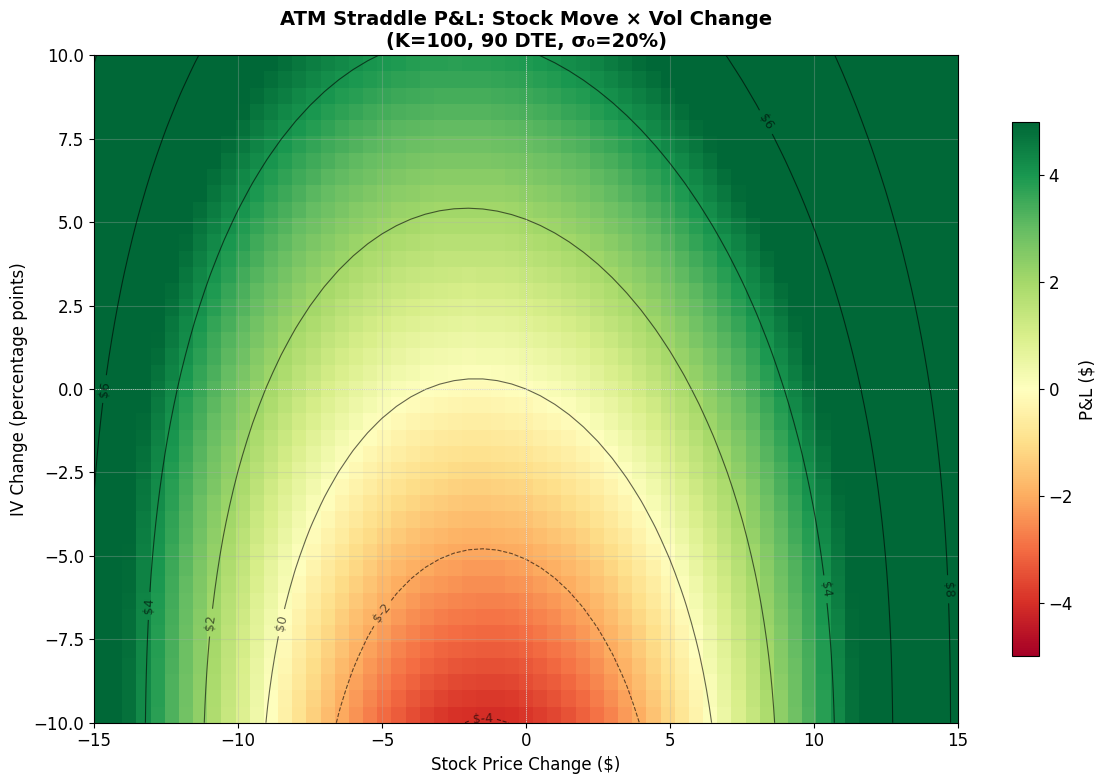

Key observations:
• Top-left / Top-right (green): large stock moves + vol increase → best case for long straddle
• Center-bottom (red): no stock move + vol crush → worst case for long straddle
• The contours show constant-P&L lines — they're curved, not straight, because of gamma


In [22]:
S_changes = np.linspace(-15, 15, 61)
vol_changes = np.linspace(-10, 10, 41)  # in percentage points

base_bs = BlackScholes(S=100, K=100, T=0.25, r=0.05, sigma=0.20)
base_straddle = base_bs.call_price() + base_bs.put_price()

pnl_matrix = np.zeros((len(vol_changes), len(S_changes)))

for i, dv in enumerate(vol_changes):
    for j, ds in enumerate(S_changes):
        new_bs = BlackScholes(S=100+ds, K=100, T=0.25, r=0.05, sigma=0.20+dv/100)
        new_straddle = new_bs.call_price() + new_bs.put_price()
        pnl_matrix[i, j] = new_straddle - base_straddle

fig, ax = plt.subplots(figsize=(12, 8))
extent = [S_changes[0], S_changes[-1], vol_changes[0], vol_changes[-1]]
im = ax.imshow(pnl_matrix, aspect='auto', origin='lower', extent=extent,
               cmap='RdYlGn', vmin=-5, vmax=5)

# Contour lines
cs = ax.contour(S_changes, vol_changes, pnl_matrix,
                levels=[-4, -2, 0, 2, 4, 6, 8], colors='black', linewidths=0.8, alpha=0.6)
ax.clabel(cs, fmt='$%.0f', fontsize=9)

ax.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax.axvline(0, color='white', linewidth=0.5, linestyle=':')
ax.set_xlabel('Stock Price Change ($)', fontsize=12)
ax.set_ylabel('IV Change (percentage points)', fontsize=12)
ax.set_title('ATM Straddle P&L: Stock Move × Vol Change\n(K=100, 90 DTE, σ₀=20%)',
             fontsize=14, fontweight='bold')
fig.colorbar(im, label='P&L ($)', shrink=0.8)
plt.tight_layout()
plt.show()

print("Key observations:")
print("• Top-left / Top-right (green): large stock moves + vol increase → best case for long straddle")
print("• Center-bottom (red): no stock move + vol crush → worst case for long straddle")
print("• The contours show constant-P&L lines — they're curved, not straight, because of gamma")

### Exercise 3: Build Your Own Strategy

Define a custom options portfolio and visualize its Greeks. Modify the `positions` list below.

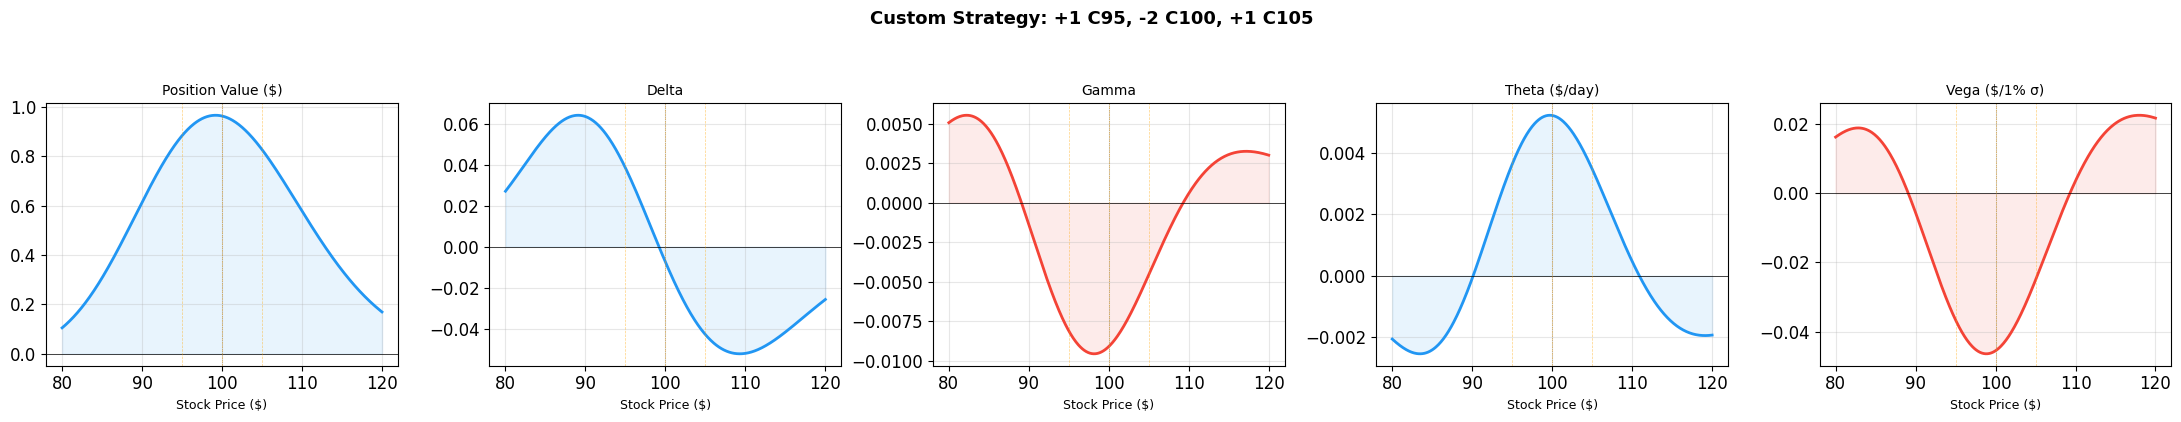

Net Greeks at S=100:
  Delta: -0.0075
  Gamma: -0.0091
  Theta: +0.0052 $/day
  Vega:  -0.0455 $/1%σ
  Value: +0.9623 $


In [23]:
# Define your strategy: (quantity, 'call'/'put', strike)
# Positive qty = long, negative = short
my_positions = [
    (+1, 'call', 95),   # Long 1 ITM call
    (-2, 'call', 100),  # Short 2 ATM calls
    (+1, 'call', 105),  # Long 1 OTM call
]

S_range = np.linspace(80, 120, 500)
plot_strategy('Custom Strategy', my_positions, S_range)

# Print the net Greeks at current spot
greeks = portfolio_greeks(my_positions, np.array([100.0]))
print("Net Greeks at S=100:")
print(f"  Delta: {greeks['delta'][0]:+.4f}")
print(f"  Gamma: {greeks['gamma'][0]:+.4f}")
print(f"  Theta: {greeks['theta'][0]:+.4f} $/day")
print(f"  Vega:  {greeks['vega'][0]:+.4f} $/1%σ")
print(f"  Value: {greeks['value'][0]:+.4f} $")

### Exercise 4: Implied Volatility Solver

Given an observed market price, back out the implied volatility using Newton-Raphson. Vega is the derivative we need for the iteration:

$$\sigma_{n+1} = \sigma_n - \frac{C_{\text{BS}}(\sigma_n) - C_{\text{market}}}{\nu(\sigma_n)}$$

In [24]:
def implied_vol(market_price, S, K, T, r, option_type='call', tol=1e-8, max_iter=100):
    sigma = 0.20  # initial guess
    history = []

    for i in range(max_iter):
        bs = BlackScholes(S=S, K=K, T=T, r=r, sigma=sigma)
        price = bs.call_price() if option_type == 'call' else bs.put_price()
        vega_raw = bs.vega() * 100  # undo the /100 scaling

        diff = price - market_price
        history.append((i, sigma, price, diff))

        if abs(diff) < tol:
            break
        if vega_raw < 1e-12:
            break

        sigma -= diff / vega_raw
        sigma = max(sigma, 1e-4)

    return sigma, history


# Example: find IV for a call trading at $8.50
market_price = 8.50
iv, history = implied_vol(market_price, S=100, K=100, T=0.25, r=0.05)

print(f"Market call price: ${market_price:.2f}")
print(f"Implied volatility: {iv:.4%}")
print("\nNewton-Raphson convergence:")
print(f"{'Iter':>4} {'σ':>10} {'BS Price':>10} {'Error':>12}")
for it, s, p, d in history:
    print(f"{it:4d} {s:10.6f} {p:10.6f} {d:12.2e}")

# Verify
bs_check = BlackScholes(S=100, K=100, T=0.25, r=0.05, sigma=iv)
print(f"\nVerification: BS price at σ={iv:.4%} is ${bs_check.call_price():.6f}")

Market call price: $8.50
Implied volatility: 39.7328%

Newton-Raphson convergence:
Iter          σ   BS Price        Error
   0   0.200000   4.614997    -3.89e+00
   1   0.397770   8.508716     8.72e-03
   2   0.397328   8.500000    -2.88e-08
   3   0.397328   8.500000     7.11e-15

Verification: BS price at σ=39.7328% is $8.500000


### Exercise 5: Volatility Smile

Compute implied volatilities across strikes from synthetic market prices to see the classic volatility smile pattern.

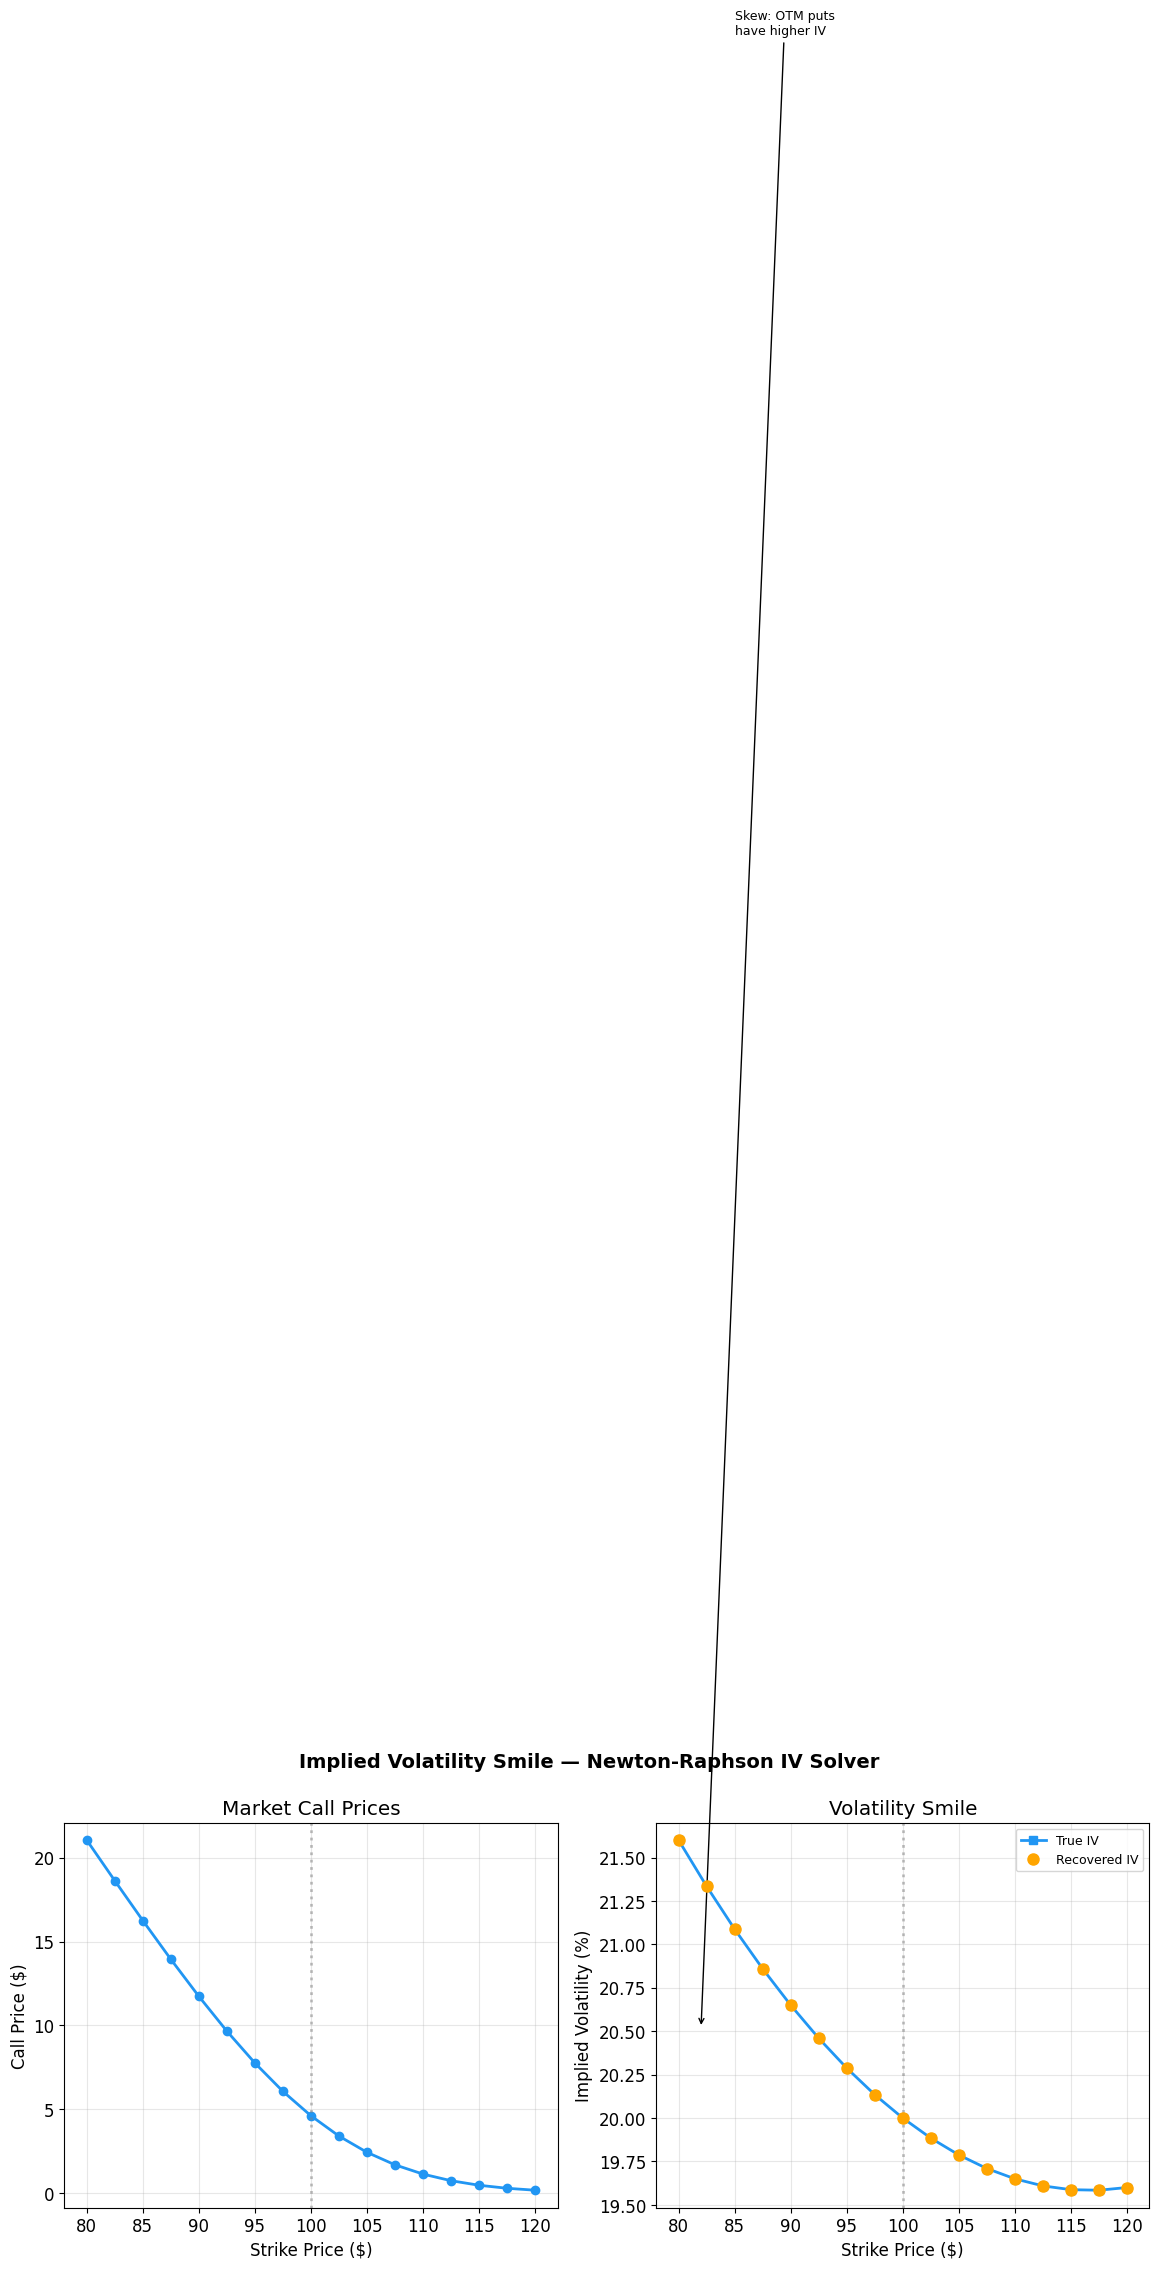

In [32]:
# Simulate a market with skew: OTM puts have higher IV than ATM
strikes = np.arange(80, 121, 2.5)
true_ivs = 0.20 + 0.15 * ((100 - strikes) / 100)**2 + 0.05 * (100 - strikes) / 100

# Generate "market" prices from these IVs
market_prices = []
for K, iv in zip(strikes, true_ivs):
    bs = BlackScholes(S=100, K=K, T=0.25, r=0.05, sigma=iv)
    market_prices.append(bs.call_price())

# Recover IVs from prices (as if we only observed prices)
recovered_ivs = []
for K, price in zip(strikes, market_prices):
    iv, _ = implied_vol(price, S=100, K=K, T=0.25, r=0.05)
    recovered_ivs.append(iv)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(strikes, [p for p in market_prices], 'o-', color=CALL_COLOR)
axes[0].set_xlabel('Strike Price ($)')
axes[0].set_ylabel('Call Price ($)')
axes[0].set_title('Market Call Prices')
axes[0].axvline(100, color='gray', linestyle=':', alpha=0.5)

axes[1].plot(strikes, [iv*100 for iv in true_ivs], 's-', label='True IV', color=CALL_COLOR, markersize=6)
axes[1].plot(strikes, [iv*100 for iv in recovered_ivs], 'o', label='Recovered IV',
             color='orange', markersize=8, zorder=5)
axes[1].set_xlabel('Strike Price ($)')
axes[1].set_ylabel('Implied Volatility (%)')
axes[1].set_title('Volatility Smile')
axes[1].axvline(100, color='gray', linestyle=':', alpha=0.5)
axes[1].legend(fontsize=9)
axes[1].annotate('Skew: OTM puts\nhave higher IV', xy=(82, true_ivs[0]*100),
                 xytext=(85, 32), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='black'))

plt.suptitle('Implied Volatility Smile — Newton-Raphson IV Solver', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Summary

| Greek | Call | Put | Peaks at | Practical use |
|-------|------|-----|----------|---------------|
| **Delta** | 0 to +1 | -1 to 0 | Deep ITM | Hedge ratio, directional exposure |
| **Gamma** | Always ≥ 0 | Always ≥ 0 | ATM, near expiry | Hedging cost, convexity P&L |
| **Theta** | Usually ≤ 0 | Usually ≤ 0 | ATM, near expiry | Time decay, income strategies |
| **Vega** | Always ≥ 0 | Always ≥ 0 | ATM, far expiry | Vol trading, earnings plays |
| **Rho** | ≥ 0 | ≤ 0 | Deep ITM, far expiry | LEAPS, rate-sensitive trades |

**Key relationships to remember:**
- Long gamma costs theta; short gamma earns theta.
- Vega and gamma both peak ATM, but vega favors longer-dated, gamma favors shorter-dated.
- Greeks are additive — portfolio risk = sum of individual position Greeks.
- The Black-Scholes Greeks are a starting point; real markets have skew, term structure, and jumps.